# 00 Exploratory Data Analysis (EDA)

*Autores: Verónica Gamo, Alexandru Stoia, Daniel Olivier Domínguez, Oliver Pereira*

**Empresa consultora: Stratton Oakmont Consulting** 

En este primer notebook, realizaremos una exploración integral del dataset crudo `TRAIN.txt` para entender las distribuciones de las variables iniciales, el comportamiento de la variable objetivo (la Producción) a lo largo de los años y, críticamente, la naturaleza de los valores faltantes o anómalos.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración de los gráficos
plt.style.use('ggplot')
sns.set_palette("Set2")
sns.set_context("notebook", font_scale=1.1)

# Cargar los datos crudos
df = pd.read_csv('data/TRAIN.txt', sep='|')

# Aseguramos que SUPERFICIE es numérica para que la comprobación de cantidad de ceros sea confiable
df['SUPERFICIE'] = pd.to_numeric(df['SUPERFICIE'], errors='coerce')

# Castear Altitud directamente
df["ALTITUD"] = pd.to_numeric(df["ALTITUD"], errors="coerce")
df["ALTITUD"] = df["ALTITUD"].astype(float)

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (8526, 11)


,CAMPAÑA,ID_FINCA,ID_ZONA,ID_ESTACION,ALTITUD,VARIEDAD,MODO,TIPO,COLOR,SUPERFICIE,PRODUCCION
0,14,76953,515,4,660.0,26,2,0,1,0.0,22215.0
1,14,84318,515,4,660.0,26,2,0,1,0.0,22215.0
2,14,85579,340,4,520.0,32,2,0,1,0.0,20978.0
3,14,69671,340,4,520.0,32,2,0,1,0.0,40722.0
4,14,14001,852,14,NaN,81,1,0,1,0.0,14126.0


## 1. Visión General de los Datos y Faltantes (NAs)
Conocer dónde y cuándo faltan datos es el primer paso para saber qué técnicas de imputación necesitaremos en el notebook de preprocesamiento.

In [12]:
print("--- Tipos de datos y resúmenes de nulos ---")
print(df.info())

--- Tipos de datos y resúmenes de nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8526 entries, 0 to 8525
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CAMPAÑA      8526 non-null   int64  
 1   ID_FINCA     8526 non-null   int64  
 2   ID_ZONA      8526 non-null   int64  
 3   ID_ESTACION  8526 non-null   int64  
 4   ALTITUD      1109 non-null   float64
 5   VARIEDAD     8526 non-null   int64  
 6   MODO         8526 non-null   int64  
 7   TIPO         8526 non-null   int64  
 8   COLOR        8526 non-null   int64  
 9   SUPERFICIE   8526 non-null   float64
 10  PRODUCCION   7482 non-null   float64
dtypes: float64(3), int64(8)
memory usage: 732.8 KB
None


In [14]:
print("--- Conteo de Valores Nulos (NAs Reales) por Variable ---")
display(df.isnull().sum())

--- Conteo de Valores Nulos (NAs Reales) por Variable ---


CAMPAÑA           0
ID_FINCA          0
ID_ZONA           0
ID_ESTACION       0
ALTITUD        7417
VARIEDAD          0
MODO              0
TIPO              0
COLOR             0
SUPERFICIE        0
PRODUCCION     1044
dtype: int64

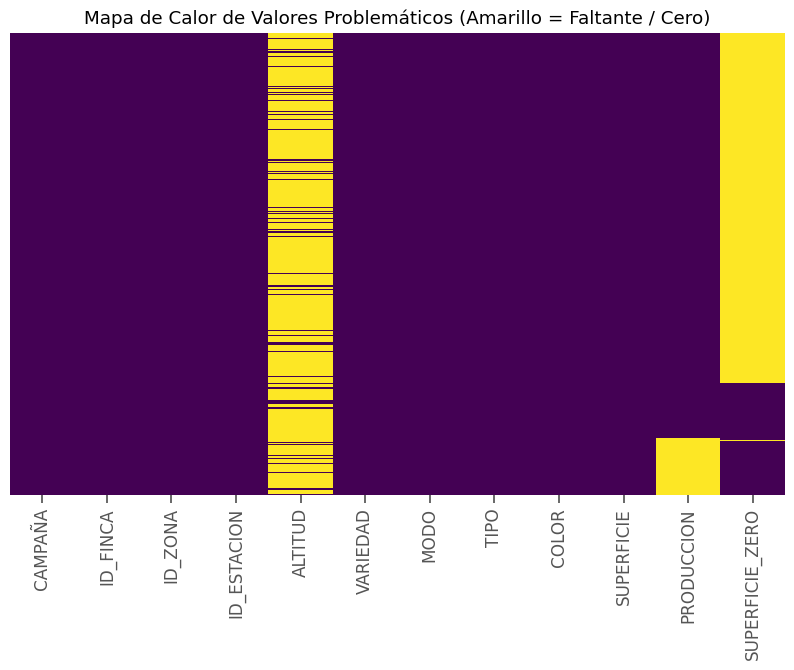

In [15]:
# Mapa de Calor de Valores Nulos y Ceros
plt.figure(figsize=(10, 6))
# Consideramos visualmente defectuosos tanto NAs como ceros en superficie
heatmap_data = df.isnull()
heatmap_data['SUPERFICIE_ZERO'] = df['SUPERFICIE'] == 0.0

sns.heatmap(heatmap_data, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Problemáticos (Amarillo = Faltante / Cero)')
plt.show()

*Observación:* Notamos que variables fundamentales como `SUPERFICIE` y `ALTITUD` tienen valores problemáticos. La superficie en vez de venir como NaN viene como el valor `0.0`.
Vamos a verlo desglosado por Campaña intentando entender visualmente por qué esto es una omisión del registro original.

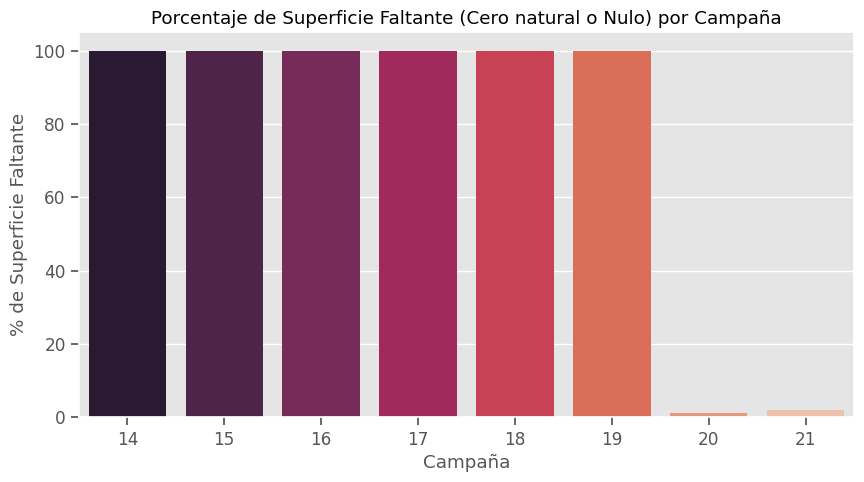

In [16]:
# Ahora pedimos que sume tanto los que son Nulos (.isnull()) como los que son literalmente cero (== 0)
nulos_por_campana = df.groupby('CAMPAÑA')['SUPERFICIE'].apply(lambda x: ((x == 0) | x.isnull()).sum() / len(x) * 100)

plt.figure(figsize=(10, 5))
sns.barplot(x=nulos_por_campana.index, y=nulos_por_campana.values, palette="rocket")
plt.title('Porcentaje de Superficie Faltante (Cero natural o Nulo) por Campaña')
plt.xlabel('Campaña')
plt.ylabel('% de Superficie Faltante')
plt.show()

Efectivamente, los años 2014 a 2019 carecen casi por completo del dato de `SUPERFICIE` (viene como un 0.0 insertado), dejando ver que sólo se documentó esta variable a partir de 2020. En nuestro diseño posterior, **tendremos que tratar los 0.0 como NaNs e imputar la superficie de años posteriores o anteriores por finca** para rellenar este hueco.

## 2. Análisis de las Continuas (Superficie y Altitud)

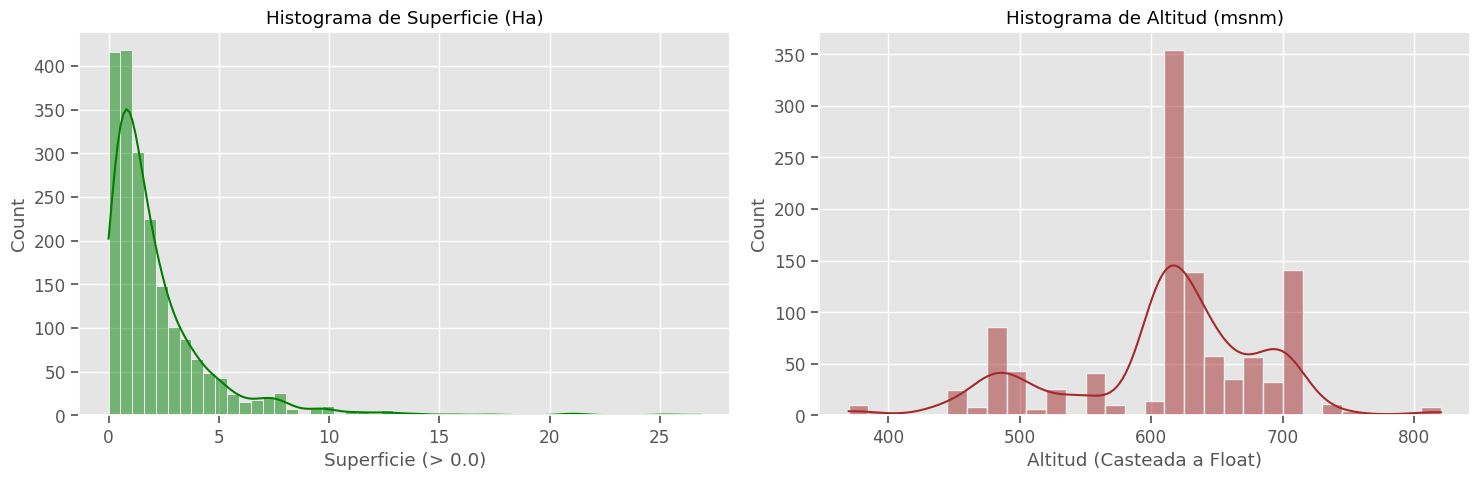

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df[df['SUPERFICIE'] > 0]['SUPERFICIE'].dropna(), bins=50, kde=True, ax=ax[0], color='green')
ax[0].set_title('Histograma de Superficie (Ha)')
ax[0].set_xlabel('Superficie (> 0.0)')

sns.histplot(df['ALTITUD'].dropna(), bins=30, kde=True, ax=ax[1], color='brown')
ax[1].set_title('Histograma de Altitud (msnm)')
ax[1].set_xlabel('Altitud (Casteada a Float)')

plt.tight_layout()
plt.show()

Ambas variables, después de ser limpiadas de sus valores cero, nos muestran sus distribuciones.

## 3. Análisis de la Variable Objetivo: PRODUCCION
Vemos cómo se comporta la producción total y su distribución a lo largo de las distintas campañas.

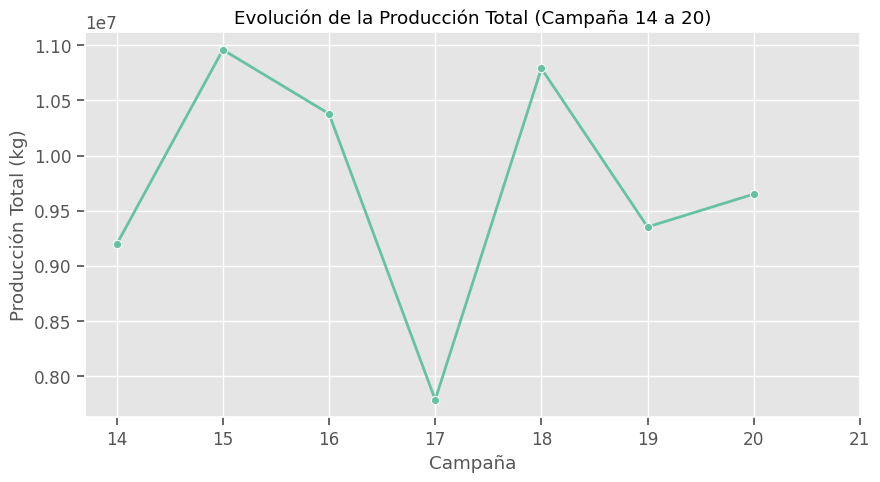

In [20]:
# Produccion Total por Campaña
prod_campana = df.groupby('CAMPAÑA')['PRODUCCION'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=prod_campana[prod_campana['CAMPAÑA'] <= 20], x='CAMPAÑA', y='PRODUCCION', marker='o', lw=2)
plt.title('Evolución de la Producción Total (Campaña 14 a 20)')
plt.xlabel('Campaña')
plt.ylabel('Producción Total (kg)')
plt.xticks(prod_campana['CAMPAÑA'].unique())
plt.show()

### Distribución Estadística de la Producción
Ver si la distribución de la producción está sesgada nos dará pistas sobre si nuestro modelo necesitará regularizaciones o transformaciones.

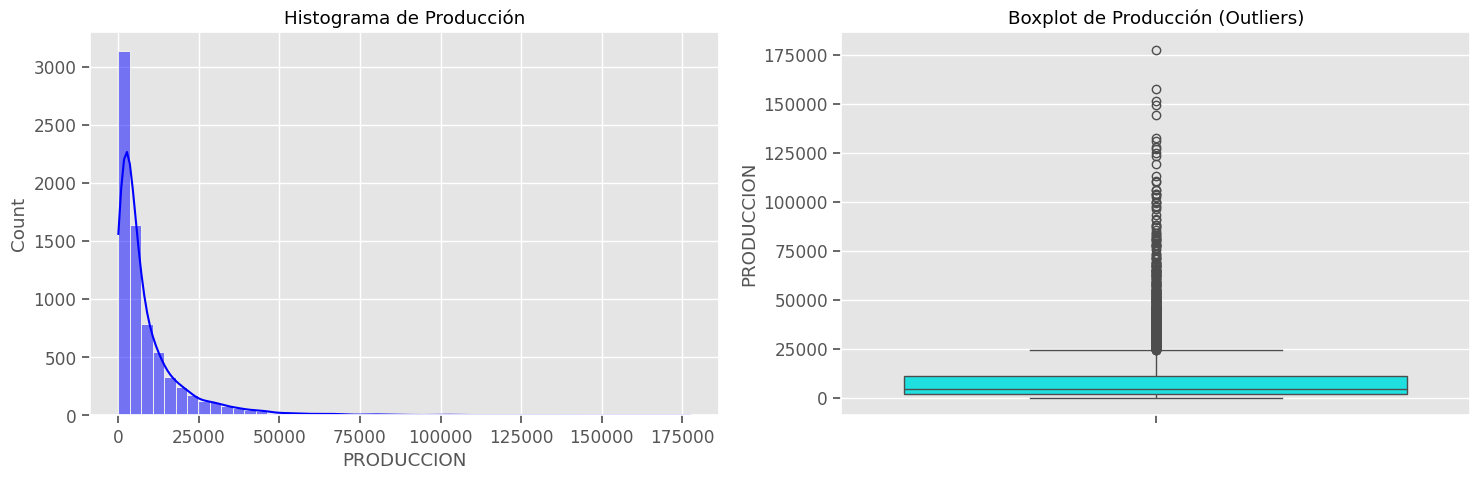

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['PRODUCCION'].dropna(), bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Histograma de Producción')

sns.boxplot(y=df['PRODUCCION'].dropna(), ax=ax[1], color='cyan')
ax[1].set_title('Boxplot de Producción (Outliers)')

plt.tight_layout()
plt.show()

Clara asimetría positiva a la derecha: la mayoría de fincas declaran una baja a moderada producción, con algunos valores extraordinariamente altos (*Outliers* naturales dados por la superficie o el año). Modelos basados en árboles suelen manejar bien esta asimetría sin logaritmos.

## 4. Comportamiento de las Categorías de Producción del Vino

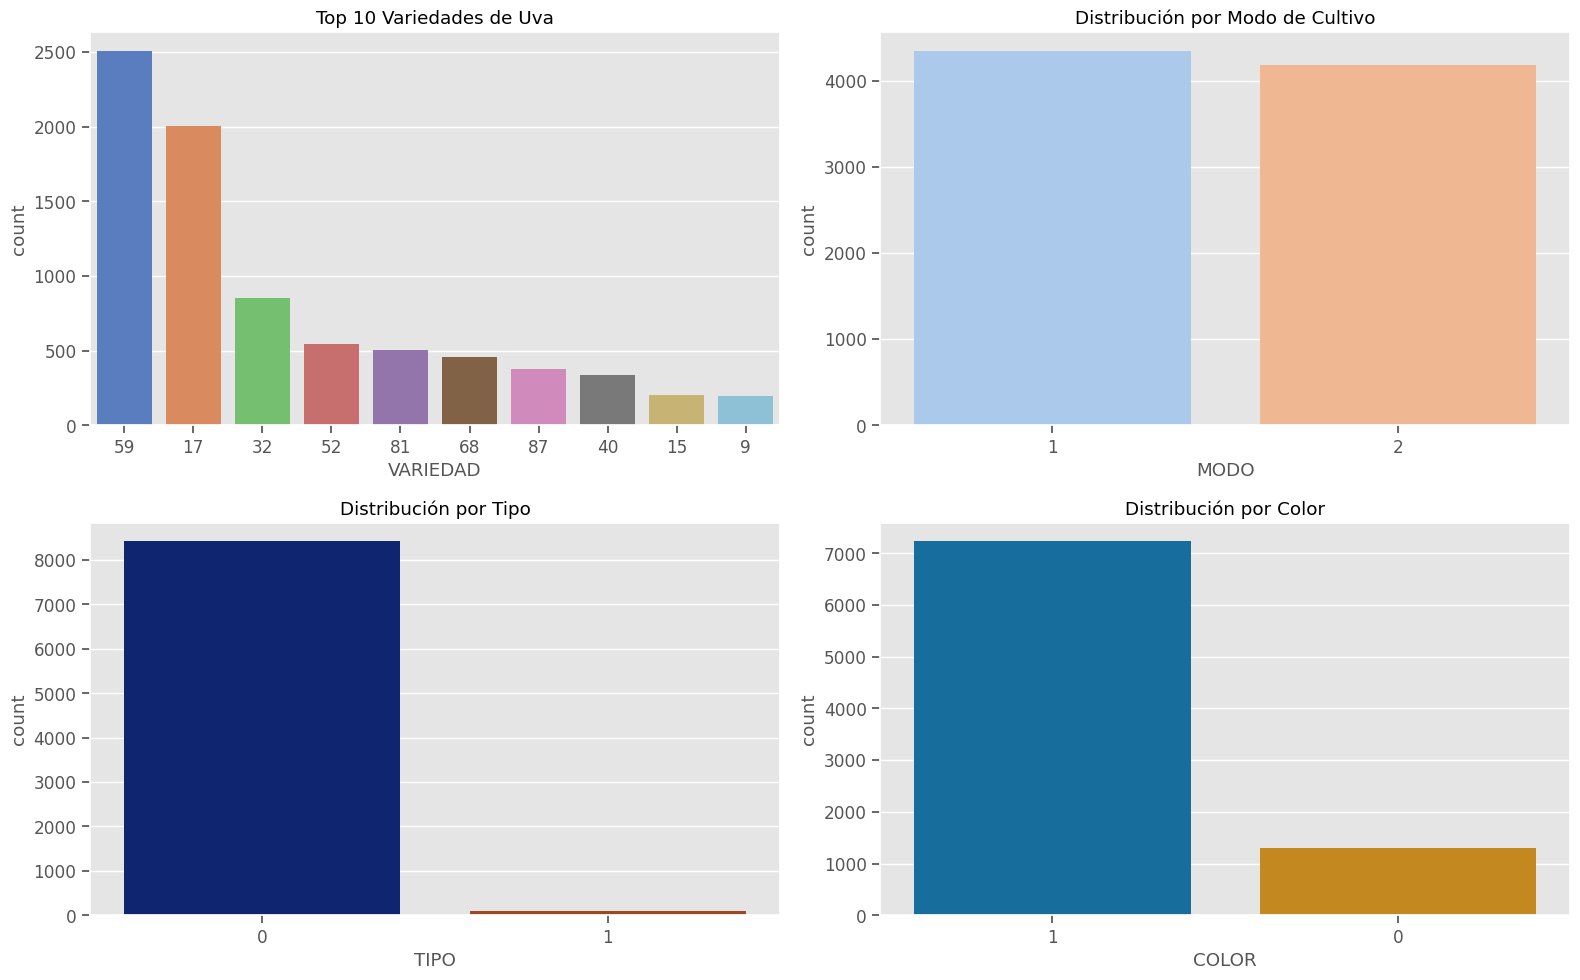

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='VARIEDAD', ax=axes[0,0], order=df['VARIEDAD'].value_counts().index[:10], palette="muted")
axes[0,0].set_title('Top 10 Variedades de Uva')

sns.countplot(data=df, x='MODO', ax=axes[0,1], order=df['MODO'].value_counts().index, palette="pastel")
axes[0,1].set_title('Distribución por Modo de Cultivo')

sns.countplot(data=df, x='TIPO', ax=axes[1,0], order=df['TIPO'].value_counts().index, palette="dark")
axes[1,0].set_title('Distribución por Tipo')

sns.countplot(data=df, x='COLOR', ax=axes[1,1], order=df['COLOR'].value_counts().index, palette="colorblind")
axes[1,1].set_title('Distribución por Color')

plt.tight_layout()
plt.show()

Es un dataset muy concentrado en un puñado específico de Variedades, un par de Modos y la predominancia del Color 1. Al haber categorías dominantes, el **One-Hot Encoding** que aplicaremos en la etapa de modelado será altamente efectivo para capturar los nichos específicos.

Observamos también que tanto en las distribuciones por tipo y por color hay un desbalance de las categorías considerable. Punto a tener en cuenta en la fase de entrenamiento.

## 5. Conclusiones para la Fase de Preprocesamiento (`01_Preprocessing`)

1. **Requerimiento de Imputación Lógica de SUPERFICIE**: Usar agrupaciones por Finca (`ID_FINCA`) y arrastrar (*forward/backward fill*) los datos recogidos en 2020/2021 hacia los años previos donde la superficie era figurativamente `0.0`. 
2. **Casteo de Altitud**: La conversión inicial cruda manda a NaNs a las etiquetas de tipo string `500-600` pero nos avisa para su procesamiento pormenorizado o imputación luego.
3. **Mantenimiento de los Outliers**: La producción tiene una "larga cola", lo cual en un contexto agrícola es normal (Fincas monstruosamente grandes o años excepcionales). No decapitaremos los valores altos.
4. **OHE**: Recomendada transformación `pd.get_dummies` sobre Variedad, Modo, Tipo, Color, Zona y Estación para explotarlas a fondo.
5. **Desbalanceo de clases**: Tanto en la variable `Tipo` y `Color` 

Damos por finalizado nuestro Análisis Exploratorio de Datos. Procedamos con `01_Preprocessing.ipynb`.